In [1]:
import pandas as pd
import numpy as np
import os
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
DATA_PATH = os.path.join("..", "data", "raw", "delivery_logistics.csv")
MODEL_DIR = os.path.join("..", "models")
os.makedirs(MODEL_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (25000, 15)


,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delayed,delivery_status,delivery_rating,delivery_cost
0,250.99,delhivery,automobile parts,bike,same day,west,clear,297.0,46.96,1970-01-01 00:00:00.000000008,1970-01-01 00:00:00.000000008,no,delivered,3,1632.7206
1,250.99,xpressbees,cosmetics,ev van,express,central,cold,89.6,47.39,1970-01-01 00:00:00.000000002,1970-01-01 00:00:00.000000003,no,delivered,5,640.1700
2,250.99,shadowfax,groceries,truck,two day,east,rainy,273.5,26.89,1970-01-01 00:00:00.000000010,1970-01-01 00:00:00.000000016,no,delivered,4,1448.1700
3,250.99,dhl,electronics,ev van,same day,east,cold,269.7,12.69,1970-01-01 00:00:00.000000006,1970-01-01 00:00:00.000000008,no,delivered,3,1486.5700
4,250.99,dhl,clothing,van,two day,north,foggy,256.7,37.02,1970-01-01 00:00:00.000000009,1970-01-01 00:00:00.000000016,no,delivered,4,1394.5600


In [3]:
def extract_hours_from_corrupted_timestamp(value: str) -> float:
    
    try:
        nanosecond_part = value.split(".")[-1]
        hours = int(nanosecond_part)
        return float(hours)
    except (ValueError, IndexError):
        return np.nan

df["delivery_time_hours"] = df["delivery_time_hours"].apply(extract_hours_from_corrupted_timestamp)
df["expected_time_hours"] = df["expected_time_hours"].apply(extract_hours_from_corrupted_timestamp)

df = df.dropna(subset=["delivery_time_hours", "expected_time_hours"])
df = df.drop(columns=["delivery_id"])  # confirmed to be a meaningless sequential float, not a real ID

print(f"Cleaned shape: {df.shape}")
df[["delivery_time_hours", "expected_time_hours"]].describe()

Cleaned shape: (25000, 14)


,delivery_time_hours,expected_time_hours
count,25000.000000,25000.000000
mean,6.248040,13.107680
std,3.140935,7.559024
min,0.000000,2.000000
25%,4.000000,8.000000
50%,6.000000,8.000000
75%,8.000000,16.000000
max,19.000000,24.000000


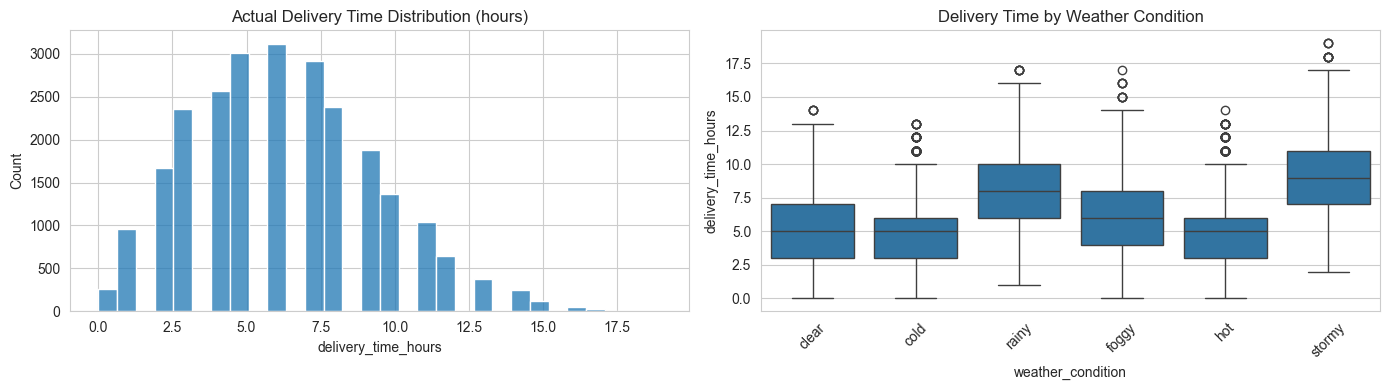

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df["delivery_time_hours"], bins=30, ax=axes[0])
axes[0].set_title("Actual Delivery Time Distribution (hours)")

sns.boxplot(data=df, x="weather_condition", y="delivery_time_hours", ax=axes[1])
axes[1].set_title("Delivery Time by Weather Condition")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [5]:
categorical_cols = [
    "delivery_partner", "package_type", "vehicle_type",
    "delivery_mode", "region", "weather_condition",
]
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col + "_enc"] = le.fit_transform(df[col])
    encoders[col] = le

feature_cols = [
    "delivery_partner_enc", "package_type_enc", "vehicle_type_enc",
    "delivery_mode_enc", "region_enc", "weather_condition_enc",
    "distance_km", "package_weight_kg", "expected_time_hours",
]

X = df[feature_cols]
y = df["delivery_time_hours"]
print(f"Features: {len(feature_cols)}, Rows: {len(X)}")

Features: 9, Rows: 25000


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

def evaluate_model(name, model, X_test, y_test):
    predictions = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    print(f"{name}: RMSE={rmse:.2f}h, MAE={mae:.2f}h, R²={r2:.4f}")
    return {"name": name, "rmse": rmse, "mae": mae, "r2": r2, "model": model}

results = []

Train size: 20000, Test size: 5000


In [7]:
lr = LinearRegression()
lr.fit(X_train, y_train)
results.append(evaluate_model("Linear Regression", lr, X_test, y_test))

Linear Regression: RMSE=1.85h, MAE=1.48h, R²=0.6463


In [8]:
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
results.append(evaluate_model("Random Forest", rf, X_test, y_test))

Random Forest: RMSE=1.64h, MAE=1.30h, R²=0.7211


In [9]:
xgb_model = xgb.XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)
results.append(evaluate_model("XGBoost", xgb_model, X_test, y_test))

XGBoost: RMSE=1.67h, MAE=1.31h, R²=0.7133


               Model      RMSE       MAE        R2
0  Linear Regression  1.850950  1.480712  0.646328
1      Random Forest  1.643649  1.300183  0.721112
2            XGBoost  1.666404  1.312240  0.713337


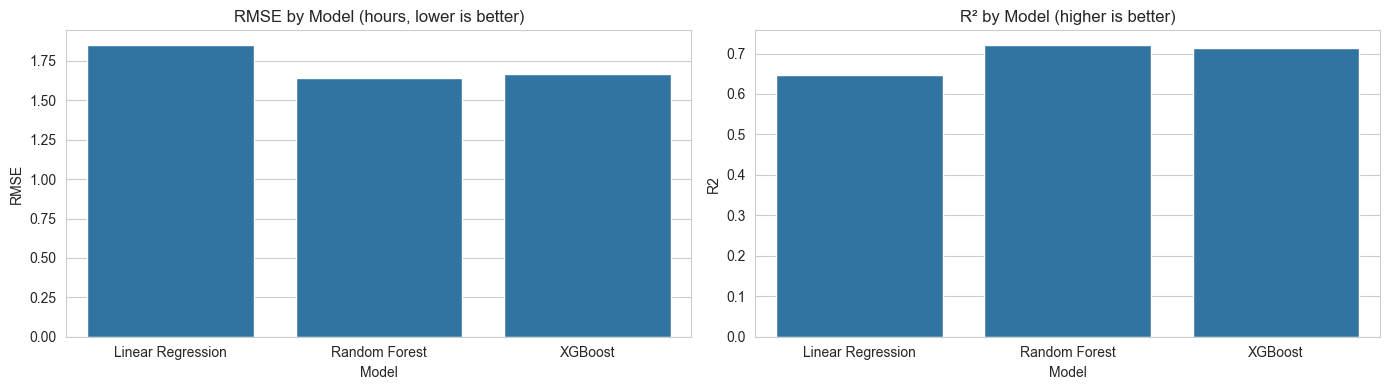

In [10]:
comparison_df = pd.DataFrame([{"Model": r["name"], "RMSE": r["rmse"], "MAE": r["mae"], "R2": r["r2"]} for r in results])
print(comparison_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(data=comparison_df, x="Model", y="RMSE", ax=axes[0])
axes[0].set_title("RMSE by Model (hours, lower is better)")
sns.barplot(data=comparison_df, x="Model", y="R2", ax=axes[1])
axes[1].set_title("R² by Model (higher is better)")
plt.tight_layout()
plt.show()

Best model: Random Forest


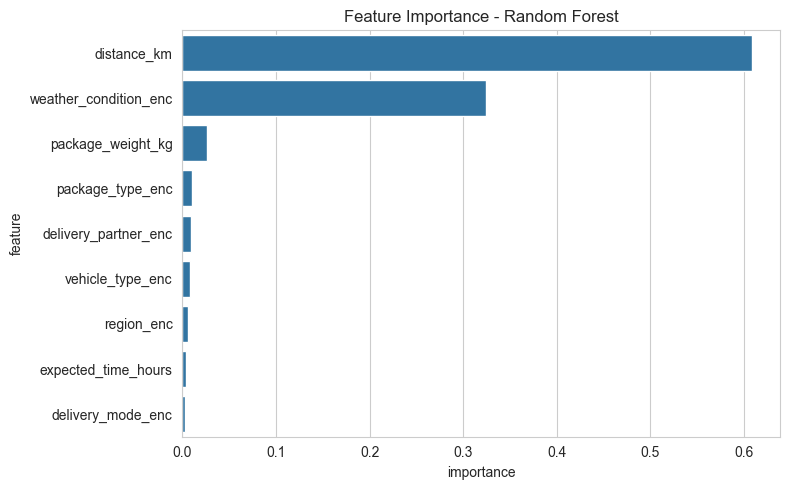

In [11]:
best = min(results, key=lambda r: r["rmse"])
print(f"Best model: {best['name']}")

if hasattr(best["model"], "feature_importances_"):
    importance_df = pd.DataFrame({
        "feature": feature_cols,
        "importance": best["model"].feature_importances_
    }).sort_values("importance", ascending=False)

    plt.figure(figsize=(8, 5))
    sns.barplot(data=importance_df, x="importance", y="feature")
    plt.title(f"Feature Importance - {best['name']}")
    plt.tight_layout()
    plt.show()

In [12]:
model_bundle = {
    "model": best["model"],
    "model_name": best["name"],
    "encoders": encoders,
    "feature_cols": feature_cols,
}
save_path = os.path.join(MODEL_DIR, "delivery_time_model.pkl")
joblib.dump(model_bundle, save_path)
print(f"Saved best model ({best['name']}) to {save_path}")

Saved best model (Random Forest) to ..\models\delivery_time_model.pkl
